<a href="https://colab.research.google.com/github/honeyComb1909/Collab/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 3.36k/3.36k [00:00<00:00, 5.02MB/s]

Extracting files...
Dataset loaded successfully! Shape: (303, 14)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training the model...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.5803 - loss: 0.6856 - val_accuracy: 0.5510 - val_loss: 0.6609
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6269 - loss: 0.6542 - val_accuracy: 0.5510 - val_loss: 0.6334
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6580 - loss: 0.6305 - val_accuracy: 0.6122 - val_loss: 0.6088
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6891 - loss: 0.6076 - val_accuracy: 0.6531 - val_loss: 0.5847
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7202 - loss: 0.5860 - val_accuracy: 0.7143 - val_loss: 0.5615
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7513 - loss: 0.5675 - val_accuracy: 0.6939 - val_loss: 0.5436
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7617 - loss: 0.5475 - val_accuracy: 0.7347 - val_loss: 0.5239
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7720 - loss: 0.5297 - v

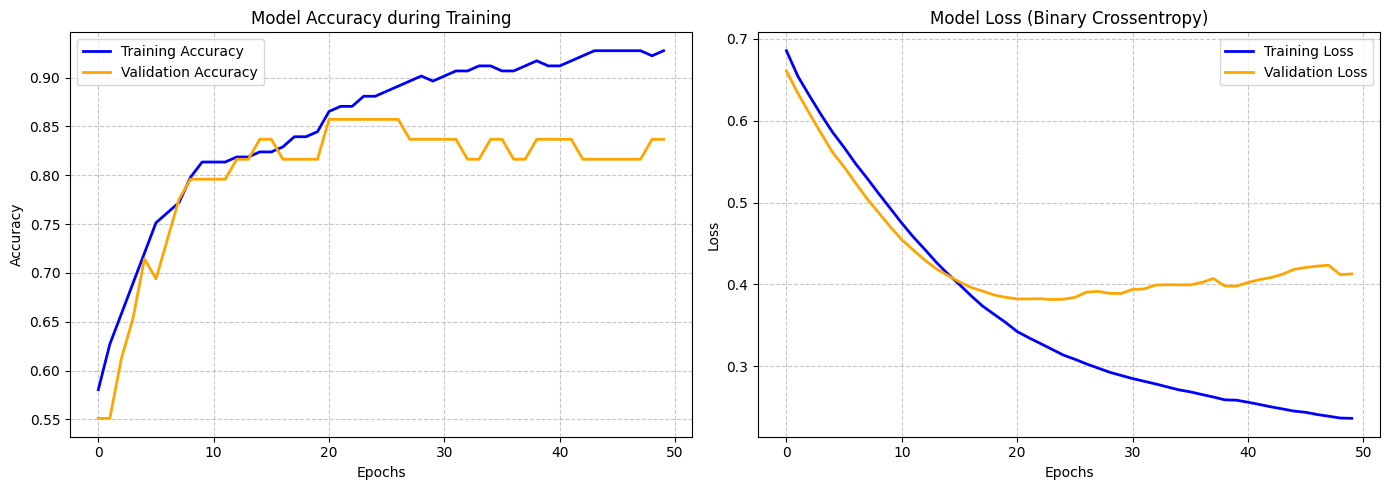

In [1]:
# !pip install kagglehub  # Uncomment and run this line if kagglehub is not installed

import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ==========================================
# 1. Download and Load Dataset
# ==========================================
print("Downloading dataset...")
path = kagglehub.dataset_download("arezaei81/heartcsv")

# Find the CSV file in the downloaded directory
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
csv_path = os.path.join(path, csv_file)

df = pd.read_csv(csv_path)
print(f"Dataset loaded successfully! Shape: {df.shape}")

# ==========================================
# 2. Data Preprocessing
# ==========================================
# Automatically detect the target column (usually 'target' or the last column)
target_col = 'target' if 'target' in df.columns else df.columns[-1]

# Separate features (X) and labels (y)
X = df.drop(columns=[target_col])
y = df[target_col]

# Split the data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Neural networks require scaled data for gradient descent/back-propagation to work efficiently
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 3. Build the Artificial Neural Network
# ==========================================
model = Sequential([
    # Input layer and first hidden layer (ReLU activation introduces non-linearity)
    Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)),

    # Second hidden layer
    Dense(8, activation='relu'),

    # Output layer (Sigmoid activation for Binary Classification: outputs a probability between 0 and 1)
    Dense(1, activation='sigmoid')
])

# Compile the model
# The 'adam' optimizer utilizes the back-propagation algorithm to calculate gradients and update weights
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# ==========================================
# 4. Train the Model (Applying Back-propagation)
# ==========================================
print("\nTraining the model...")
history = model.fit(X_train_scaled,
                    y_train,
                    epochs=50,           # Number of forward and backward passes
                    batch_size=16,       # Number of samples per gradient update
                    validation_split=0.2,# Use 20% of training data for validation
                    verbose=1)

# ==========================================
# 5. Evaluate the Model
# ==========================================
print("\nEvaluating model on unseen test data...")
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# ==========================================
# 6. Plot Training Graphs
# ==========================================
plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy during Training')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Model Loss (Binary Crossentropy)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Using Colab cache for faster access to the 'heartcsv' dataset.
Path to dataset files: /kaggle/input/heartcsv
Dataset loaded successfully! Shape: (303, 14)
Detected 2 distinct classes in the target column.
Note: The dataset only has 2 classes. The network will treat this as a 2-class categorical problem.

Training the model...
Epoch 1/60


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5803 - loss: 0.6852 - val_accuracy: 0.7551 - val_loss: 0.5596
Epoch 2/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6891 - loss: 0.5678 - val_accuracy: 0.7755 - val_loss: 0.4867
Epoch 3/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7927 - loss: 0.5032 - val_accuracy: 0.7755 - val_loss: 0.4459
Epoch 4/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8238 - loss: 0.4611 - val_accuracy: 0.7959 - val_loss: 0.4245
Epoch 5/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8394 - loss: 0.4325 - val_accuracy: 0.8163 - val_loss: 0.4019
Epoch 6/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8446 - loss: 0.4086 - val_accuracy: 0.8163 - val_loss: 0.3890
Epoch 7/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8446 - loss: 0.3943 - val_accuracy: 0.8367 - val_loss: 0.3793
Epoch 8/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8601 - loss: 0.3771 - val_accuracy: 0.8163 - val_loss: 0.3748
Ep

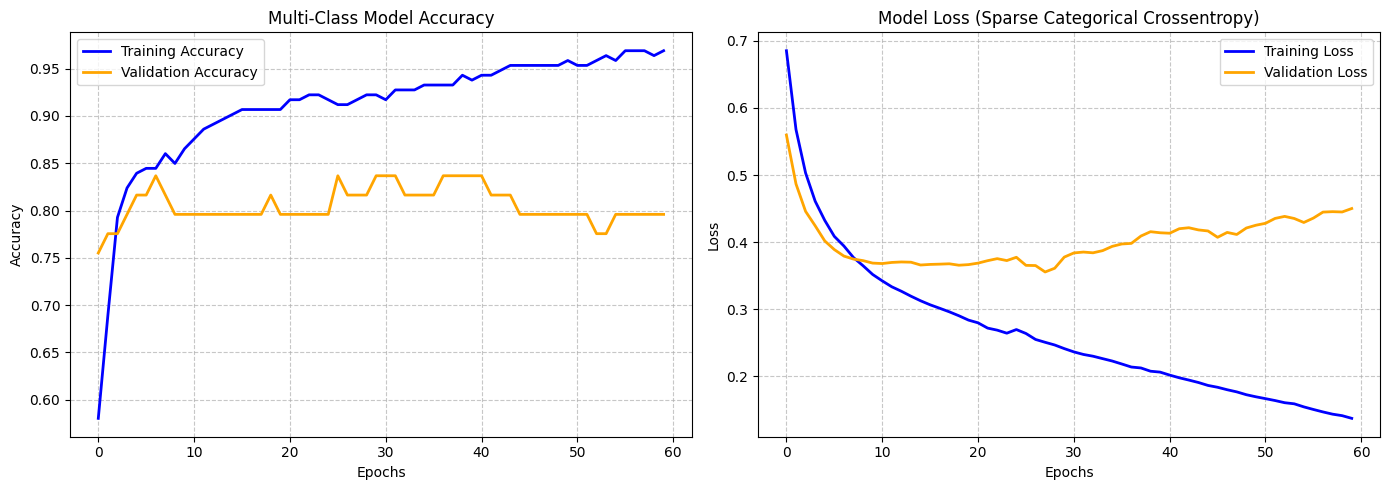

In [2]:
# !pip install kagglehub  # Uncomment and run this line if kagglehub is not installed

import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ==========================================
# 1. Download and Load Dataset
# ==========================================
print("Downloading dataset...")
path = kagglehub.dataset_download("arezaei81/heartcsv")
print("Path to dataset files:", path)

# Find the CSV file in the downloaded directory
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
csv_path = os.path.join(path, csv_file)

df = pd.read_csv(csv_path)
print(f"Dataset loaded successfully! Shape: {df.shape}")

# ==========================================
# 2. Data Preprocessing & Class Detection
# ==========================================
# Automatically detect the target column (usually 'target' or the last column)
target_col = 'target' if 'target' in df.columns else df.columns[-1]

X = df.drop(columns=[target_col])
y_raw = df[target_col]

# Use LabelEncoder to safely map target values to 0, 1, 2... (required for multi-class)
encoder = LabelEncoder()
y = encoder.fit_transform(y_raw)
num_classes = len(np.unique(y))

print(f"Detected {num_classes} distinct classes in the target column.")
if num_classes == 2:
    print("Note: The dataset only has 2 classes. The network will treat this as a 2-class categorical problem.")

# Split the data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features for stable back-propagation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 3. Build the Artificial Neural Network
# ==========================================
model = Sequential([
    # Input layer and first hidden layer
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),

    # Second hidden layer
    Dense(16, activation='relu'),

    # Output layer
    # Units = num_classes, Activation = 'softmax' ensures output probabilities sum to 1.0
    Dense(num_classes, activation='softmax')
])

# Compile the model
# 'sparse_categorical_crossentropy' is used for multi-class integer labels
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ==========================================
# 4. Train the Model (Applying Back-propagation)
# ==========================================
print("\nTraining the model...")
history = model.fit(X_train_scaled,
                    y_train,
                    epochs=60,
                    batch_size=16,
                    validation_split=0.2,
                    verbose=1)

# ==========================================
# 5. Evaluate the Model
# ==========================================
print("\nEvaluating model on unseen test data...")
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# ==========================================
# 6. Plot Training Graphs
# ==========================================
plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Multi-Class Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Model Loss (Sparse Categorical Crossentropy)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()